In [2]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU
from sklearn.model_selection import train_test_split

In [3]:
IMG_SIZE = (224, 224) # resolution
directory = "Crop___Disease/Corn"
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1  #   10% validation split
TEST_SPLIT = 0.1
num_class = 4
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
corn_validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)
# validation and test split proportions
num_val_samples = int((VALIDATION_SPLIT / (VALIDATION_SPLIT + TEST_SPLIT)) * corn_validation_dataset.cardinality().numpy())
validation_dataset = corn_validation_dataset.take(num_val_samples)
test_dataset = corn_validation_dataset.skip(num_val_samples)

print(f"Training dataset size: {len(train_dataset)} batches")
print(f"Validation dataset size: {len(validation_dataset)} batches")
print(f"Test dataset size: {len(test_dataset)} batches")

Found 14632 files belonging to 4 classes.
Using 11706 files for training.
Found 14632 files belonging to 4 classes.
Using 2926 files for validation.
Training dataset size: 366 batches
Validation dataset size: 46 batches
Test dataset size: 46 batches


In [4]:
class_names = train_dataset.class_names
class_names

['Corn___Common_Rust',
 'Corn___Gray_Leaf_Spot',
 'Corn___Healthy',
 'Corn___Leaf_Blight']

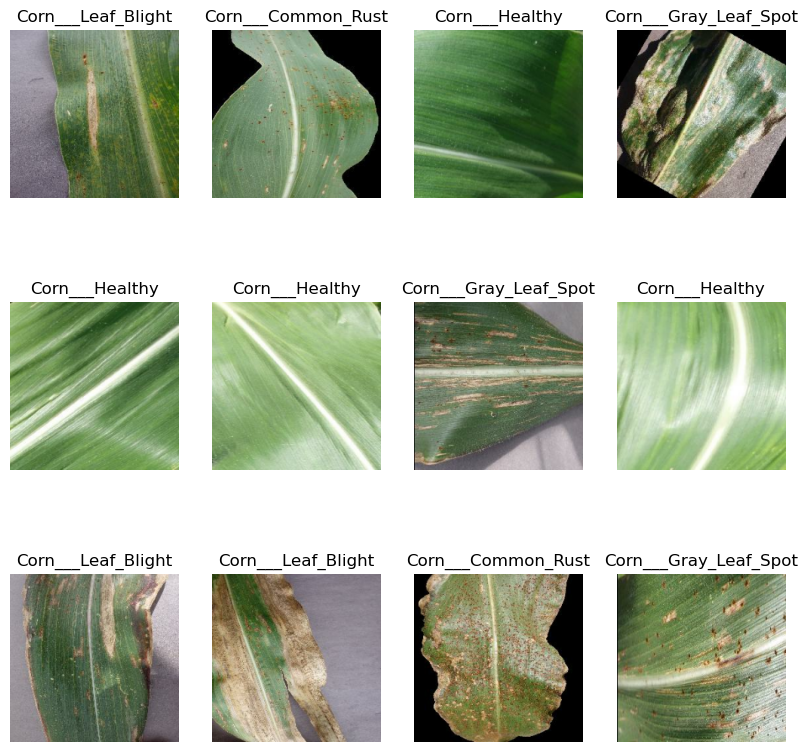

In [5]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

C:\Users\NAHID\AppData\Local\Temp\ipykernel_8880\2436110488.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")


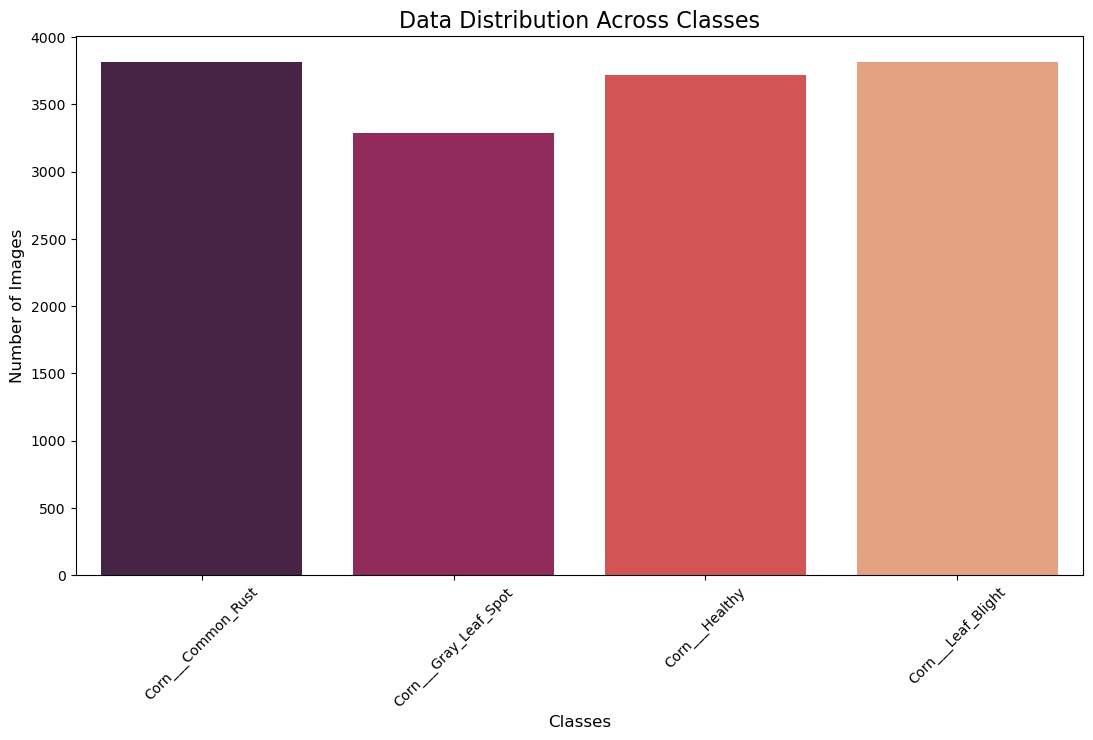

In [6]:
Data_imbalance = []
folder_names = []

# Iterate through each folder in the directory
for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)
    if os.path.isdir(folder_path):  # Ensure it's a folder
        files = gb.glob(pathname=str(folder_path + "/*.*"))
        Data_imbalance.append(len(files))
        folder_names.append(folder)  # Collect folder names dynamically

# Plot the barplot with dynamic names
plt.figure(figsize=(13, 7))
sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")
plt.title("Data Distribution Across Classes", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels if they are long
plt.show()

In [7]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)
weight_for_3 = (1 / Data_imbalance[3]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))

Weight for class 0: 0.96
Weight for class 1: 1.11
Weight for class 2: 0.98
Weight for class 3: 0.96


In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2)
])

In [9]:
import logging

# Set the logging level to suppress warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

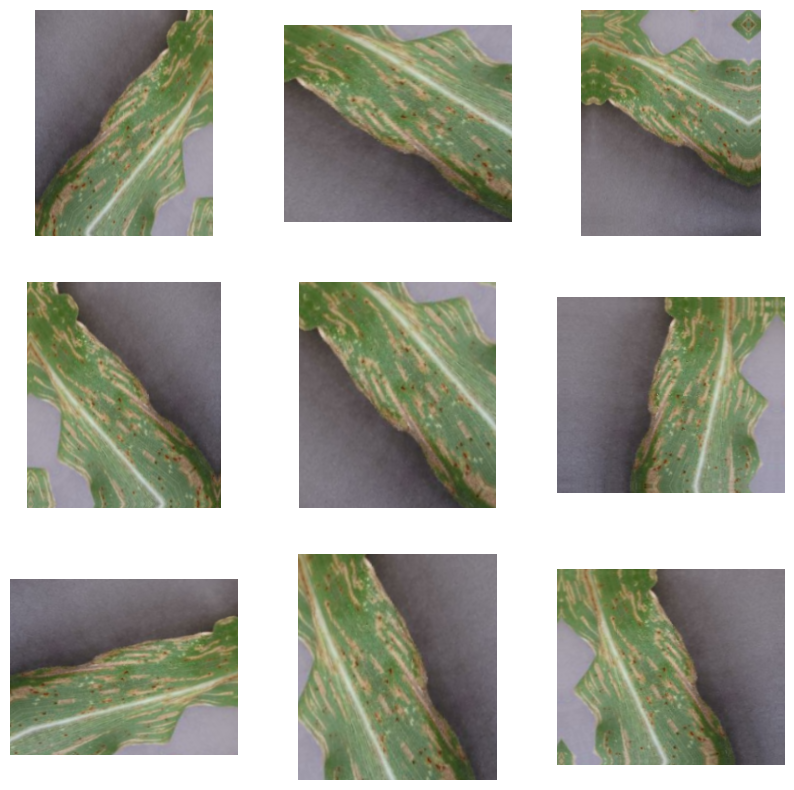

In [10]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[1]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

In [11]:
# Define mean and std for normalization
mean = tf.constant([0.485, 0.456, 0.406])  # ImageNet mean for R, G, B
std = tf.constant([0.229, 0.224, 0.225])   # ImageNet std for R, G, B

# Function to normalize after rescaling
def normalize_image(image, label):
    # Rescale image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Normalize image
    image = (image - mean) / std
    return image, label

# Apply normalization to the augmented dataset
train_dataset = train_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

In [12]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [13]:
IMG_SHAPE = IMG_SIZE + (3,)

# Load the MobileNetV2 model with pre-trained weights and without the top layers
mobilenet_base = tf.keras.applications.MobileNetV2(
    weights='imagenet',                          
    input_shape=IMG_SIZE + (3,),                 
    include_top=False                            
)

# Freeze the base model to retain pre-trained features
mobilenet_base.trainable = False

# Build the model with Sequential
mobilenet_model = tf.keras.Sequential([
    layers.Input(shape=IMG_SHAPE),               
    data_augmentation,                           
    mobilenet_base,                              
    layers.GlobalAveragePooling2D(),            
    layers.Dense(128, activation='relu'),        
    layers.Dropout(0.5),                         
    layers.Dense(num_class, activation='softmax')        
])

# Compile the MobileNetV2 model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),  
    metrics=['accuracy']                                       
)

# Display the MobileNetV2 model summary
print("\nMobileNetV2 Model Summary:")
mobilenet_model.summary()


MobileNetV2 Model Summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)          

In [14]:
# Train the Mobilenet model
print("Training Mobilenet Model...")
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    class_weight=class_weight,
    validation_data=validation_dataset,
    epochs=5
)

Training Mobilenet Model...
Epoch 1/5
366/366 [==============================] - 67s 160ms/step - loss: 0.2714 - accuracy: 0.8944 - val_loss: 0.1596 - val_accuracy: 0.9300
Epoch 2/5
366/366 [==============================] - 57s 152ms/step - loss: 0.1747 - accuracy: 0.9363 - val_loss: 0.1395 - val_accuracy: 0.9416
Epoch 3/5
366/366 [==============================] - 56s 152ms/step - loss: 0.1446 - accuracy: 0.9445 - val_loss: 0.1526 - val_accuracy: 0.9409
Epoch 4/5
366/366 [==============================] - 56s 151ms/step - loss: 0.1467 - accuracy: 0.9419 - val_loss: 0.0999 - val_accuracy: 0.9647
Epoch 5/5
366/366 [==============================] - 55s 150ms/step - loss: 0.1332 - accuracy: 0.9487 - val_loss: 0.1018 - val_accuracy: 0.9592


In [23]:
from tensorflow.keras.applications import MobileNetV2
from gradcamutils import GradCam, GradCamPlusPlus, ScoreCam, build_guided_model, GuidedBackPropagation, superimpose, read_and_preprocess_img
model = MobileNetV2(weights='imagenet',include_top=True)
layer_name = 'block_5_expand'
img_array = read_and_preprocess_img('Crop___Disease/Corn/Corn___Gray_Leaf_Spot/0e0ed08d-3021-49a7-9098-7c90afeb2fd5___RS_GLSp 4346_new30degFlipLR.jpg', size=(224,224))
grad_cam=GradCam(model,img_array,layer_name)
grad_cam_superimposed = superimpose(img_path, grad_cam)
grad_cam_emphasized = superimpose(img_path, grad_cam, emphasize=True)

## Grad cam Superimposed

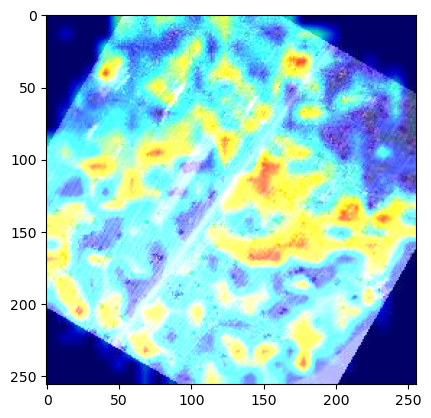

In [24]:
plt.imshow(grad_cam_superimposed)

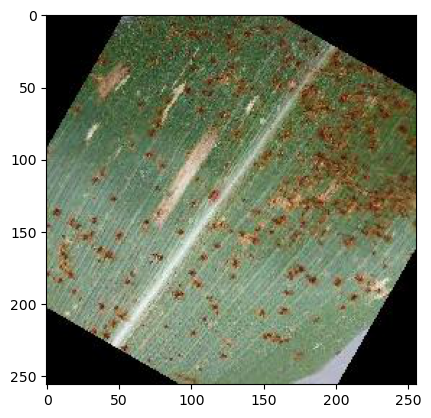

In [25]:
from tensorflow.keras.preprocessing.image import load_img

orig_img = np.array(load_img('Crop___Disease/Corn/Corn___Gray_Leaf_Spot/0e0ed08d-3021-49a7-9098-7c90afeb2fd5___RS_GLSp 4346_new30degFlipLR.jpg'),dtype=np.uint8)
plt.imshow(orig_img)
plt.show()

## Grad Cam

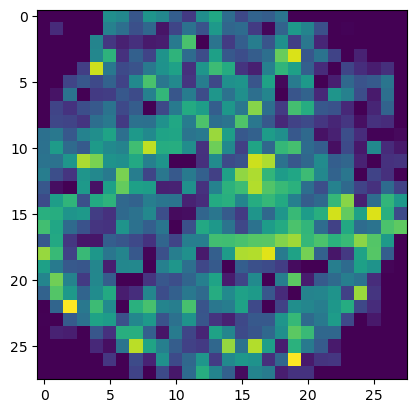

In [27]:
plt.imshow(grad_cam)
plt.show()